<a href="https://colab.research.google.com/github/superpoupette/data-tab/blob/main/notebooks/02_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/superpoupette/data-tab.git

In [1]:
!ls data-tab

data  notebooks  scripts


In [2]:
!ls data-tab/data

workouts.csv


In [3]:
import pandas as pd

workouts = pd.read_csv("data-tab/data/workouts.csv")

workouts.head()

,title,start_time,end_time,description,exercise_title,superset_id,exercise_notes,set_index,set_type,weight_kg,reps,distance_km,duration_seconds,rpe
0,Les gros pecs là 🫦,"1 juil. 2026, 06:57","1 juil. 2026, 08:02",NaN,Pull Up (Assisted),NaN,NaN,0,normal,35.0,10.0,NaN,NaN,NaN
1,Les gros pecs là 🫦,"1 juil. 2026, 06:57","1 juil. 2026, 08:02",NaN,Pull Up (Assisted),NaN,NaN,1,normal,28.0,4.0,NaN,NaN,NaN
2,Les gros pecs là 🫦,"1 juil. 2026, 06:57","1 juil. 2026, 08:02",NaN,Pull Up (Assisted),NaN,NaN,2,dropset,35.0,6.0,NaN,NaN,NaN
3,Les gros pecs là 🫦,"1 juil. 2026, 06:57","1 juil. 2026, 08:02",NaN,Pull Up (Assisted),NaN,NaN,3,normal,28.0,5.0,NaN,NaN,NaN
4,Les gros pecs là 🫦,"1 juil. 2026, 06:57","1 juil. 2026, 08:02",NaN,Pull Up (Assisted),NaN,NaN,4,dropset,35.0,5.0,NaN,NaN,NaN


In [4]:
workouts["volume"] = workouts["weight_kg"] * workouts["reps"]

In [5]:
workouts.head()

,title,start_time,end_time,description,exercise_title,superset_id,exercise_notes,set_index,set_type,weight_kg,reps,distance_km,duration_seconds,rpe,volume
0,Les gros pecs là 🫦,"1 juil. 2026, 06:57","1 juil. 2026, 08:02",NaN,Pull Up (Assisted),NaN,NaN,0,normal,35.0,10.0,NaN,NaN,NaN,350.0
1,Les gros pecs là 🫦,"1 juil. 2026, 06:57","1 juil. 2026, 08:02",NaN,Pull Up (Assisted),NaN,NaN,1,normal,28.0,4.0,NaN,NaN,NaN,112.0
2,Les gros pecs là 🫦,"1 juil. 2026, 06:57","1 juil. 2026, 08:02",NaN,Pull Up (Assisted),NaN,NaN,2,dropset,35.0,6.0,NaN,NaN,NaN,210.0
3,Les gros pecs là 🫦,"1 juil. 2026, 06:57","1 juil. 2026, 08:02",NaN,Pull Up (Assisted),NaN,NaN,3,normal,28.0,5.0,NaN,NaN,NaN,140.0
4,Les gros pecs là 🫦,"1 juil. 2026, 06:57","1 juil. 2026, 08:02",NaN,Pull Up (Assisted),NaN,NaN,4,dropset,35.0,5.0,NaN,NaN,NaN,175.0


In [6]:
mois = {
    "janv.": "Jan",
    "févr.": "Feb",
    "mars": "Mar",
    "avr.": "Apr",
    "mai": "May",
    "juin": "Jun",
    "juil.": "Jul",
    "août": "Aug",
    "sept.": "Sep",
    "oct.": "Oct",
    "nov.": "Nov",
    "déc.": "Dec"
}

for fr, en in mois.items():
    workouts["start_time"] = workouts["start_time"].str.replace(fr, en)

workouts["start_time"] = pd.to_datetime(
    workouts["start_time"],
    format="%d %b %Y, %H:%M"
)

In [7]:
workouts.head()

,title,start_time,end_time,description,exercise_title,superset_id,exercise_notes,set_index,set_type,weight_kg,reps,distance_km,duration_seconds,rpe,volume
0,Les gros pecs là 🫦,2026-07-01 06:57:00,"1 juil. 2026, 08:02",NaN,Pull Up (Assisted),NaN,NaN,0,normal,35.0,10.0,NaN,NaN,NaN,350.0
1,Les gros pecs là 🫦,2026-07-01 06:57:00,"1 juil. 2026, 08:02",NaN,Pull Up (Assisted),NaN,NaN,1,normal,28.0,4.0,NaN,NaN,NaN,112.0
2,Les gros pecs là 🫦,2026-07-01 06:57:00,"1 juil. 2026, 08:02",NaN,Pull Up (Assisted),NaN,NaN,2,dropset,35.0,6.0,NaN,NaN,NaN,210.0
3,Les gros pecs là 🫦,2026-07-01 06:57:00,"1 juil. 2026, 08:02",NaN,Pull Up (Assisted),NaN,NaN,3,normal,28.0,5.0,NaN,NaN,NaN,140.0
4,Les gros pecs là 🫦,2026-07-01 06:57:00,"1 juil. 2026, 08:02",NaN,Pull Up (Assisted),NaN,NaN,4,dropset,35.0,5.0,NaN,NaN,NaN,175.0


In [8]:
sessions = workouts.groupby("start_time").agg(
    nombre_series=("set_index", "count"),
    nombre_exercices=("exercise_title", "nunique"),
    volume_total=("volume", "sum")
)

sessions = sessions.reset_index()

In [9]:
sessions["start_time"].dtype

dtype('<M8[ns]')

In [10]:
sessions.head()

,start_time,nombre_series,nombre_exercices,volume_total
0,2026-04-22 07:02:00,15,5,7470.0
1,2026-04-26 09:08:00,21,8,2568.5
2,2026-04-28 07:02:00,18,6,7455.0
3,2026-04-29 06:59:00,17,6,3700.0
4,2026-05-04 06:59:00,19,7,7670.0


In [11]:
import matplotlib.pyplot as plt
sessions = sessions.sort_values("start_time", ascending=True)
sessions.head()


,start_time,nombre_series,nombre_exercices,volume_total
0,2026-04-22 07:02:00,15,5,7470.0
1,2026-04-26 09:08:00,21,8,2568.5
2,2026-04-28 07:02:00,18,6,7455.0
3,2026-04-29 06:59:00,17,6,3700.0
4,2026-05-04 06:59:00,19,7,7670.0


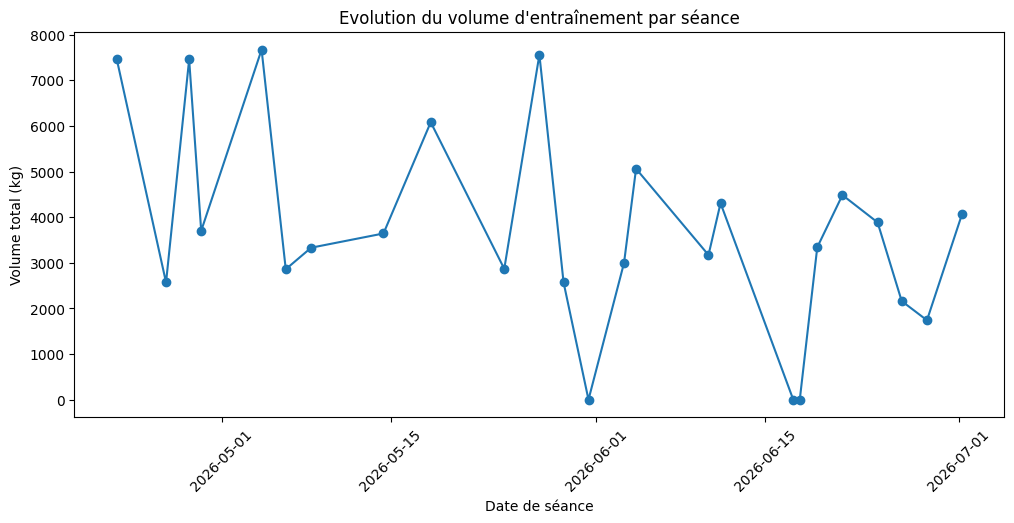

In [12]:
plt.figure(figsize=(12, 5))

plt.plot(
    sessions["start_time"],
    sessions["volume_total"],
    marker="o"
)

plt.xlabel("Date de séance")
plt.ylabel("Volume total (kg)")
plt.title("Evolution du volume d'entraînement par séance")

plt.xticks(rotation=45)

plt.show()